In [67]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def plot_waveforms_tektronix(file, save_dir=None, show=True):
    fig, ax = plt.subplots(3, 1, figsize=(8, 8))

    time = np.loadtxt(file, skiprows=17, usecols=0, delimiter=',', dtype=float)
    ch1_voltages = np.loadtxt(file, skiprows=17, usecols=1, delimiter=',', dtype=float)
    ch2_voltages = np.loadtxt(file, skiprows=17, usecols=2, delimiter=',', dtype=float)

    ax[0].plot(time, ch1_voltages, label='SiPM 1', color='yellow')
    ax[1].plot(time, ch2_voltages, label='SiPM 2', color='violet')

    ax[2].plot(time, -1*ch2_voltages, label="SiPM 2", color="#9e2a2b")
    ax[2].plot(time, -1*ch1_voltages, label="SiPM 1", color="#2b4590")
    ax[2].set_xlim(-0.4e-5,4e-5)
    ax[2].set_title("Double Pulsing from Two SiPM Channels")
    

    for axis in ax:
        axis.set_facecolor("white")
        axis.grid()
        axis.legend()
        axis.set_ylabel("Voltage [V]")

    ax[2].set_xlabel("Time [s]")

    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"{Path(file).stem}.png"
        fig.savefig(out_path, dpi=150)

    if show:
        plt.show()
    else:
        plt.close(fig)
    
def plot_waveforms_lecroy(file1, file2, save_dir=None, show=True):
    fig, ax = plt.subplots(3, 1, figsize=(8, 8))

    time1 = np.loadtxt(file1, skiprows=5, usecols=0, delimiter=',', dtype=float)
    time2 = np.loadtxt(file2, skiprows=5, usecols=0, delimiter=',', dtype=float)
    ch1_voltages = np.loadtxt(file1, skiprows=5, usecols=1, delimiter=',', dtype=float)
    ch2_voltages = np.loadtxt(file2, skiprows=5, usecols=1, delimiter=',', dtype=float)

    ax[0].plot(time1, ch1_voltages, label='SiPM 1', color='yellow')
    ax[1].plot(time2, ch2_voltages, label='SiPM 2', color='violet')

    ax[2].plot(time2, ch2_voltages, label="SiPM 2", color="#9e2a2b")
    ax[2].plot(time1, ch1_voltages, label="SiPM 1", color="#2b4590")
    ax[2].set_xlim(-0.4e-6,4e-6)
    ax[2].set_title("Single Pulsing from Two SiPM Channels")
    

    for axis in ax:
        axis.set_facecolor("white")
        axis.grid()
        axis.legend()
        axis.set_ylabel("Voltage [V]")

    ax[2].set_xlabel("Time [s]")

    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"{Path(file1).stem}.png"
        fig.savefig(out_path, dpi=150)

    if show:
        plt.show()
    else:
        plt.close(fig)

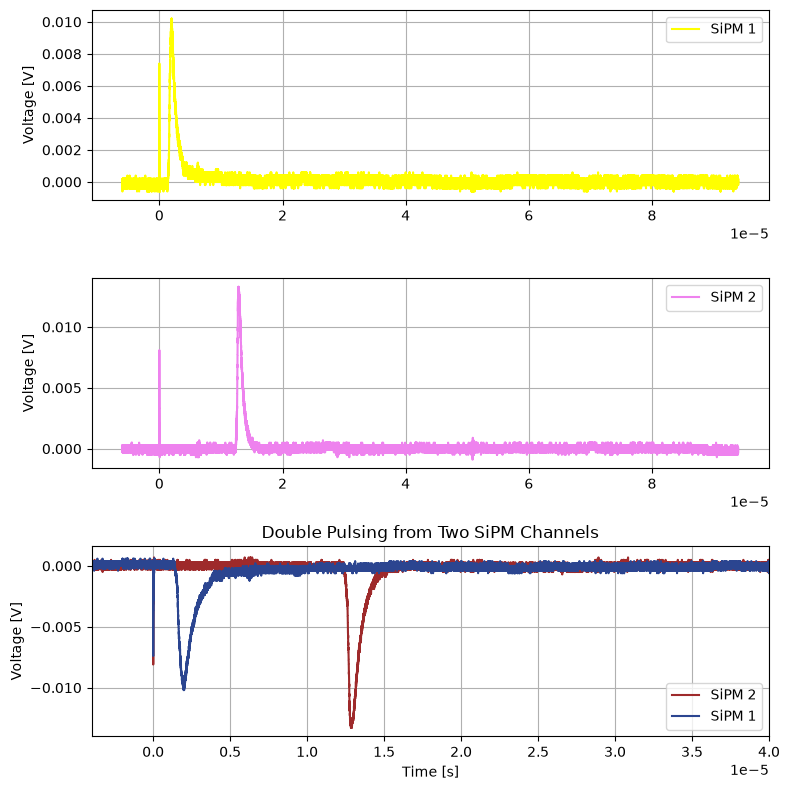

In [60]:
file = "/archive/4sepmdetectshigherupwkndrun/SaveOnEvent_ALL_20260905210639441.csv"
plot_waveforms_tektronix(file)

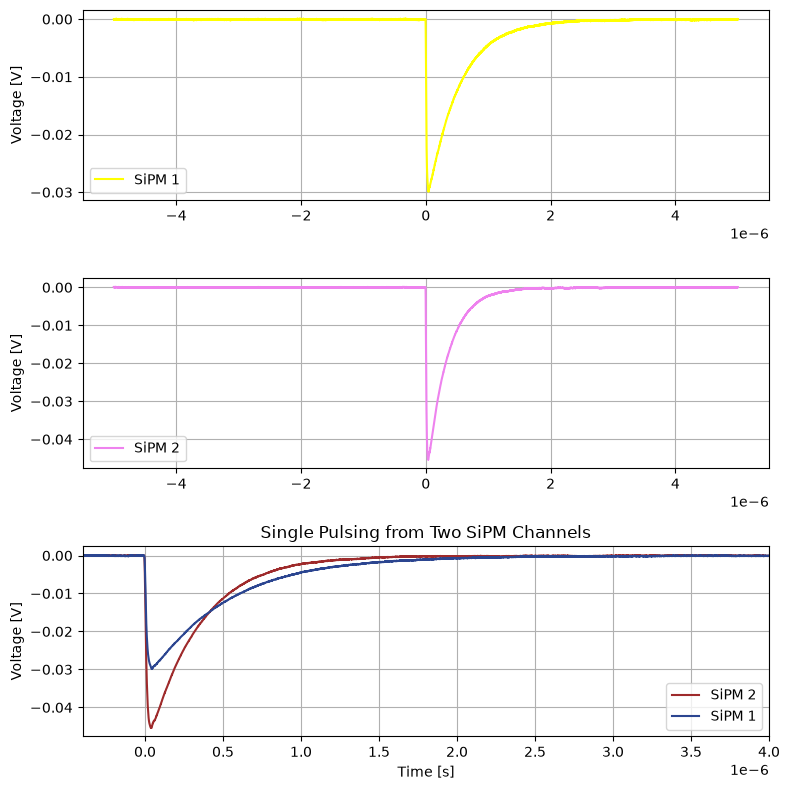

In [68]:
file1 = "/archive/24augrtmuon/24augrtmuon/C1--muon--00000.txt"
file2 = "/archive/24augrtmuon/24augrtmuon/C2--muon--00000.txt"

plot_waveforms_lecroy(file1,file2)